In [ ]:
from flower_model._clustering import _spherical_kmeans
from flower_model.external._gabor_like_filters import _gabor_like_filters
from flower_model._filterbank import _shift_filters
import torch
import matplotlib.pyplot as plt
import math
import numpy as np

In [ ]:
N = 31
sigma = 20.
k = 1000
steps = 16
SPH_KMEANS_ITERS = 100
device='cuda'

low_freq_upper= 5.
high_freq_lower = 8.

In [4]:
filters, r = _gabor_like_filters(N, sigma, 15, 1)
print(filters.shape)
print(r.shape)

/cluster/home/vetletb/projects/Bacheloroppgave-gr82-feature-extraction/src/gabor_like/external/_gaussian.py:21: RuntimeWarning: invalid value encountered in divide
  (n + np.array([l1, l2]).reshape(-1, 1, 1))


(736, 31, 31)
(736,)


In [5]:
filters = filters.astype("complex64")
filters = torch.tensor(filters, device=device)
filters = torch.abs(filters)

r = torch.tensor(r, device=device)

In [6]:
filters, _ = _shift_filters(filters, steps, N+1)
shift_dim = filters.size(dim=1)

r = r.repeat((steps*2)**2)

print(filters.shape)
print(r.shape)

torch.Size([577024, 58, 58])
torch.Size([577024])


In [7]:
filter_amount = filters.size(dim=0)
filters = filters.view(filter_amount, -1)

In [8]:
labels = _spherical_kmeans(k, filters, SPH_KMEANS_ITERS)

In [9]:
centroid_list = []
r_centroid_list = []
for cluster in range(k):
    cluster_mask = labels == cluster
    filters_in_cluster = filters[cluster_mask]
    r_in_cluster = r[cluster_mask]
    centroid_list.append(torch.mean(filters_in_cluster, dim=0))
    r_centroid_list.append(torch.mean(r_in_cluster))
centroids = torch.stack(centroid_list)
centroids_r = torch.hstack(r_centroid_list)
print(centroids.shape)
print(centroids_r.shape)
centroids = centroids.view(-1, shift_dim*shift_dim)

torch.Size([1000, 3364])
torch.Size([1000])


In [10]:
low_freq_mask = centroids_r < low_freq_upper
mid_freq_mask = (centroids_r > low_freq_upper) & (centroids_r < high_freq_lower)
high_freq_mask = centroids_r > high_freq_lower

low_freq_centroids = centroids[low_freq_mask]
high_freq_centroids = centroids[high_freq_mask]
mid_freq_centroids = centroids[mid_freq_mask]

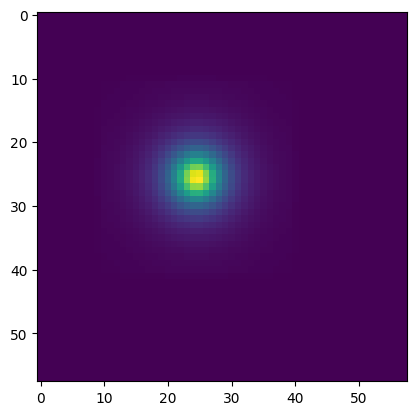

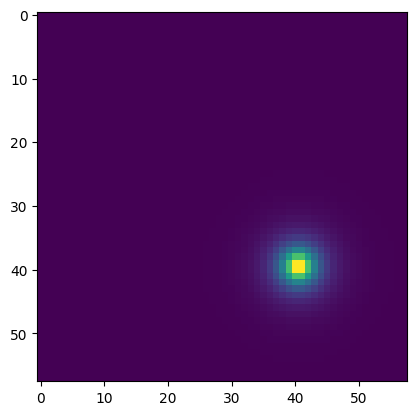

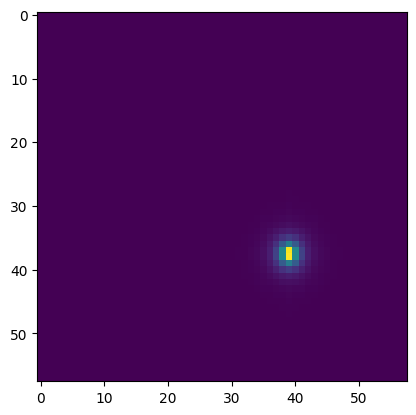

In [11]:
for c in [low_freq_centroids, mid_freq_centroids, high_freq_centroids]:
    plt.imshow(c[0].view(shift_dim, shift_dim).cpu())
    plt.show()

torch.Size([228, 3364])


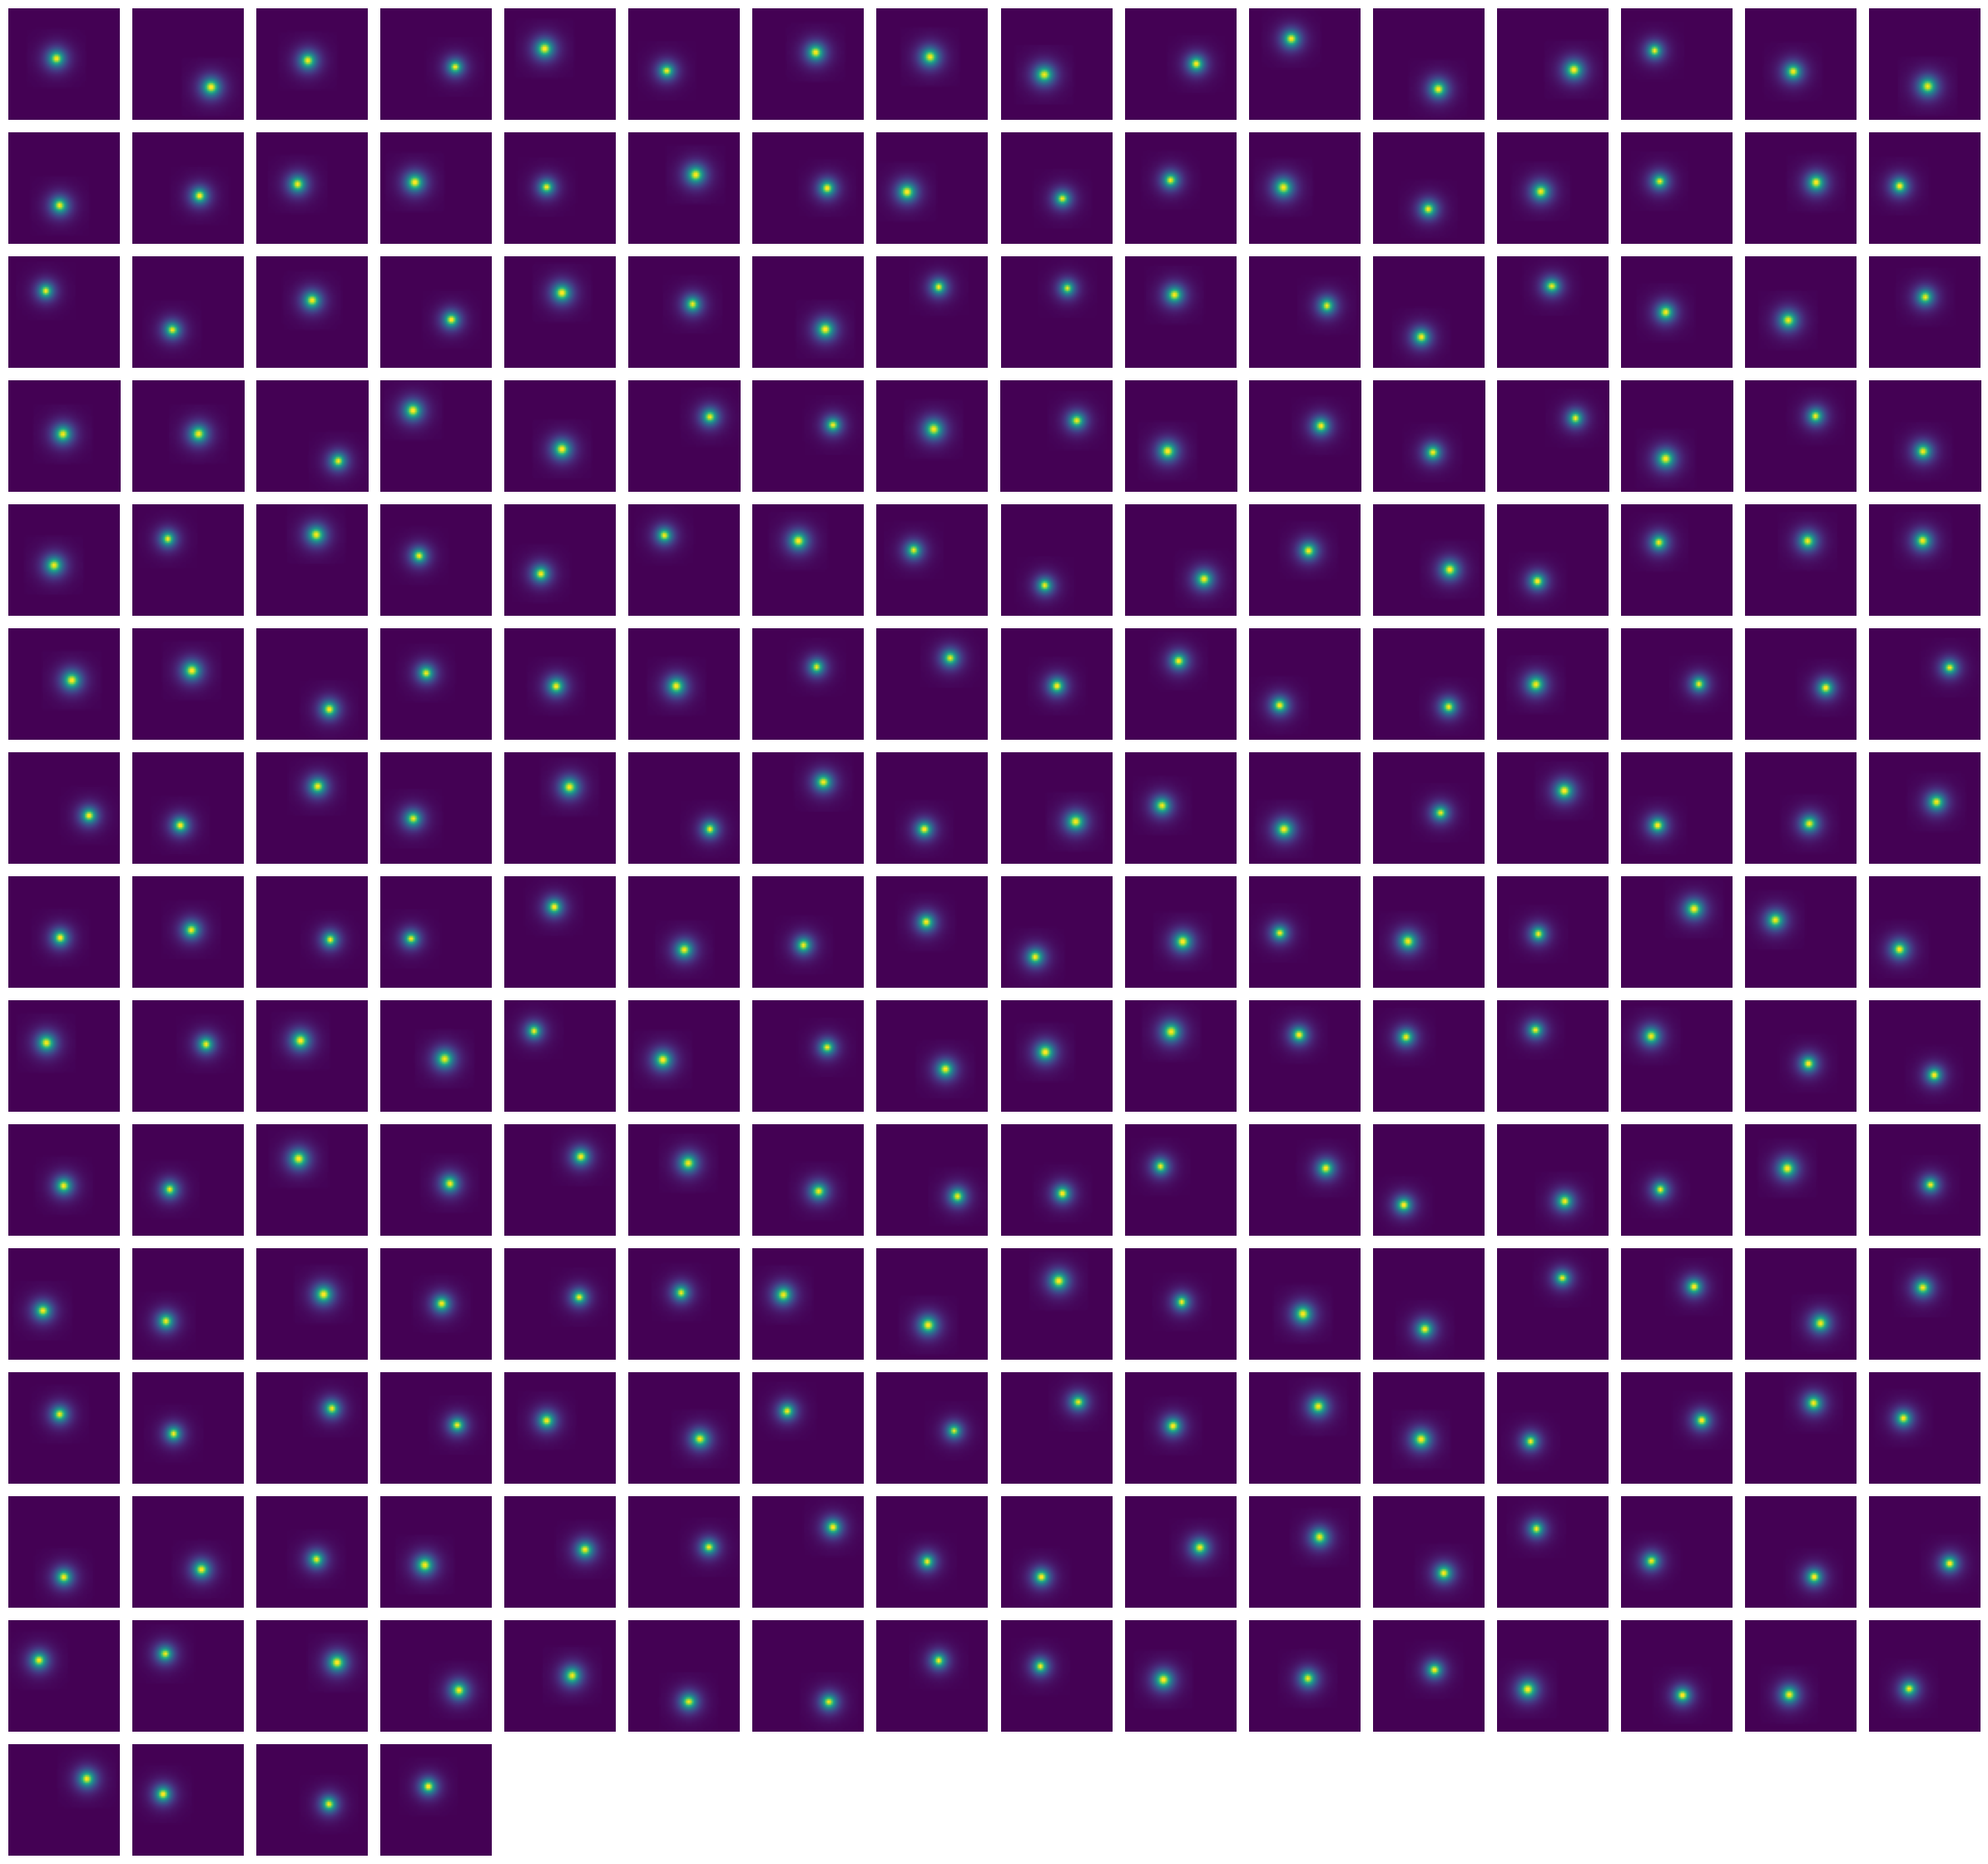

torch.Size([117, 3364])


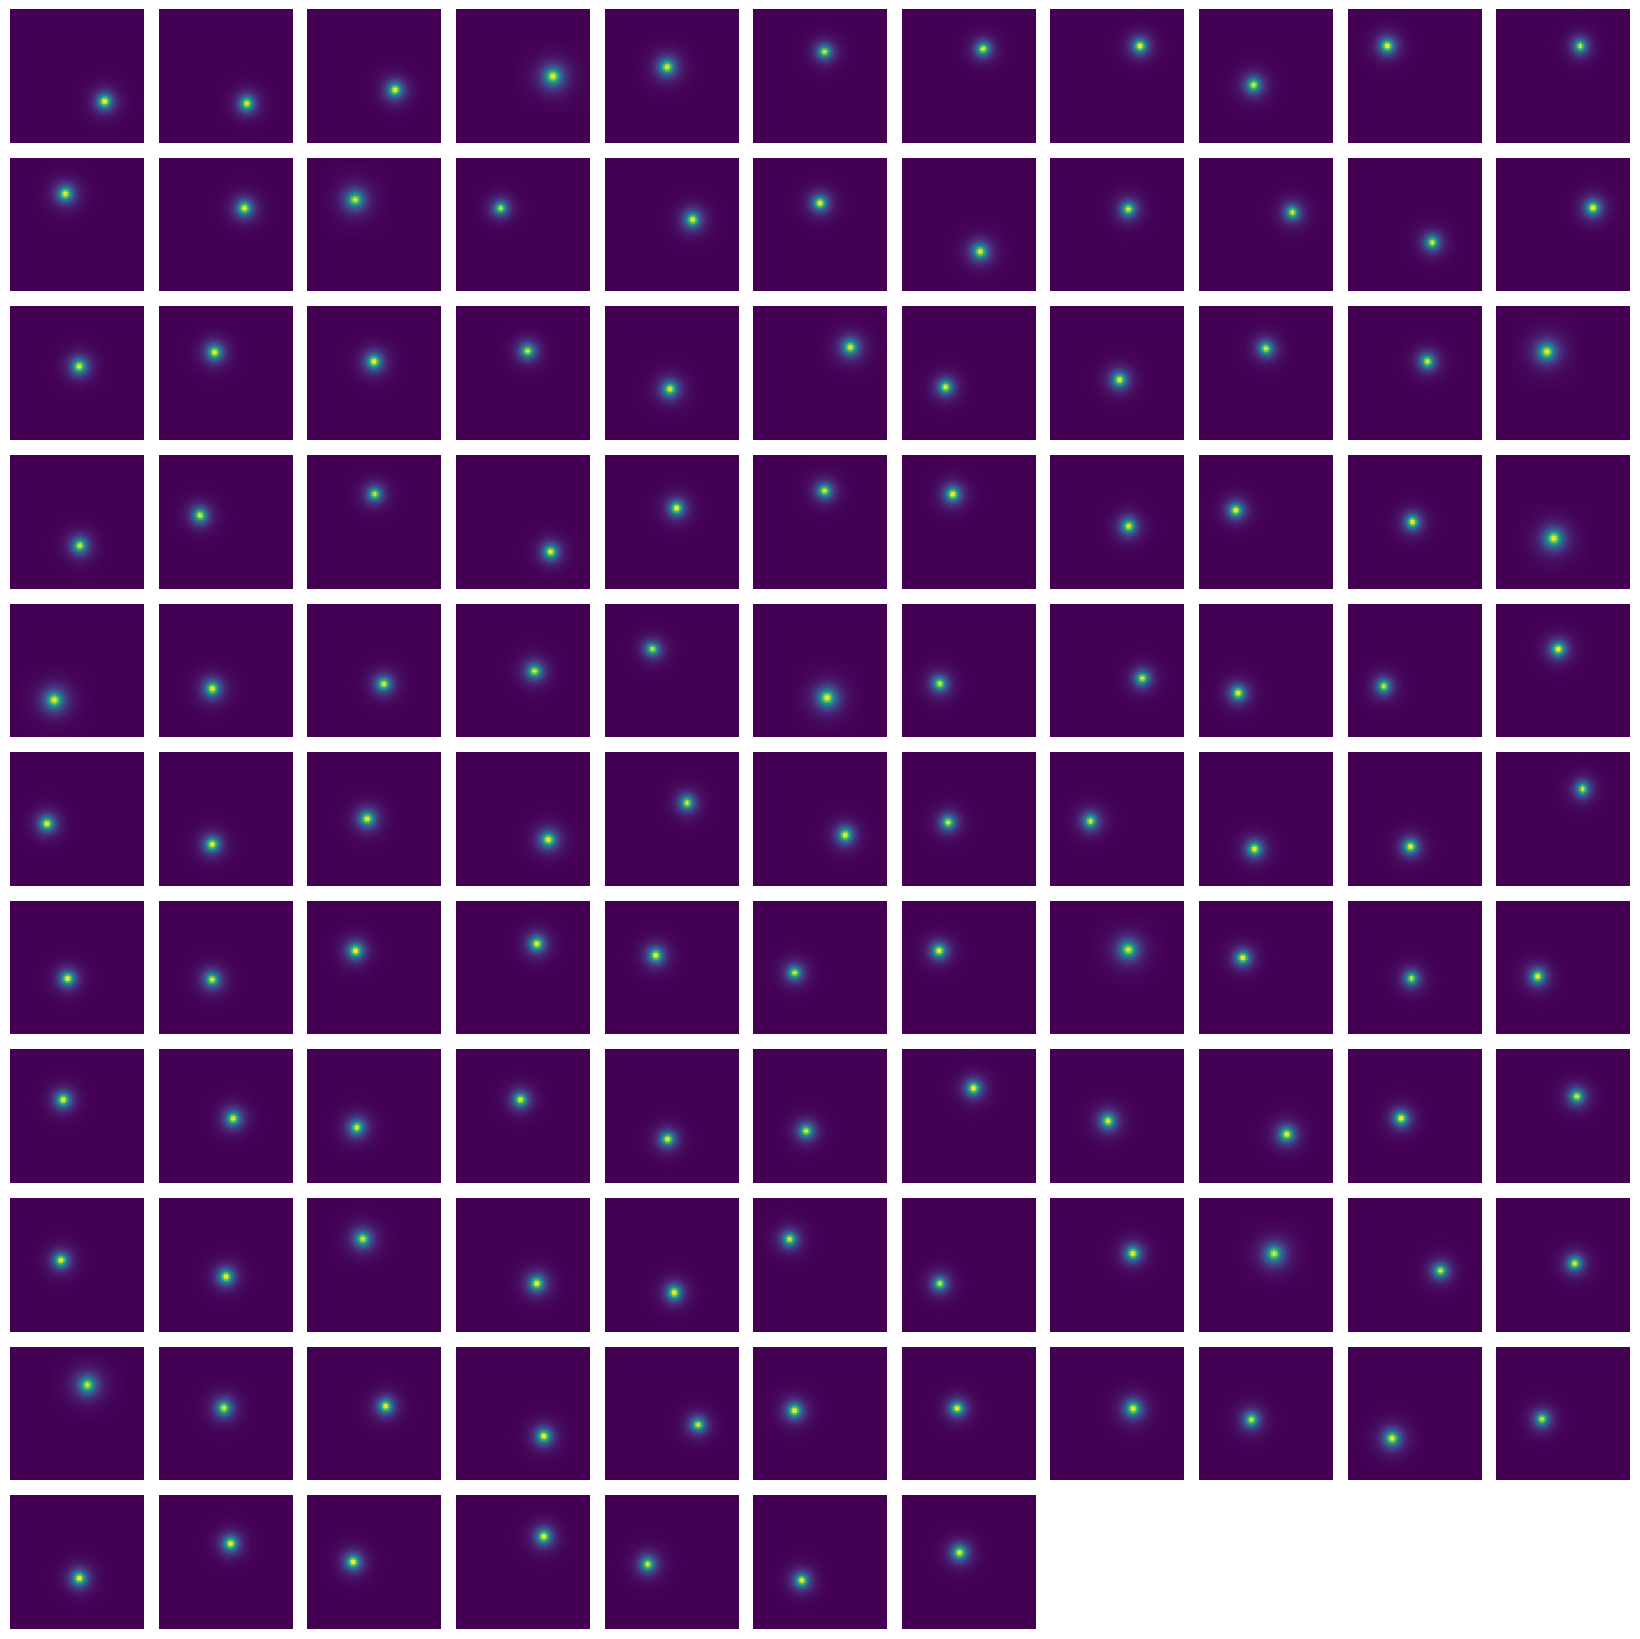

torch.Size([655, 3364])


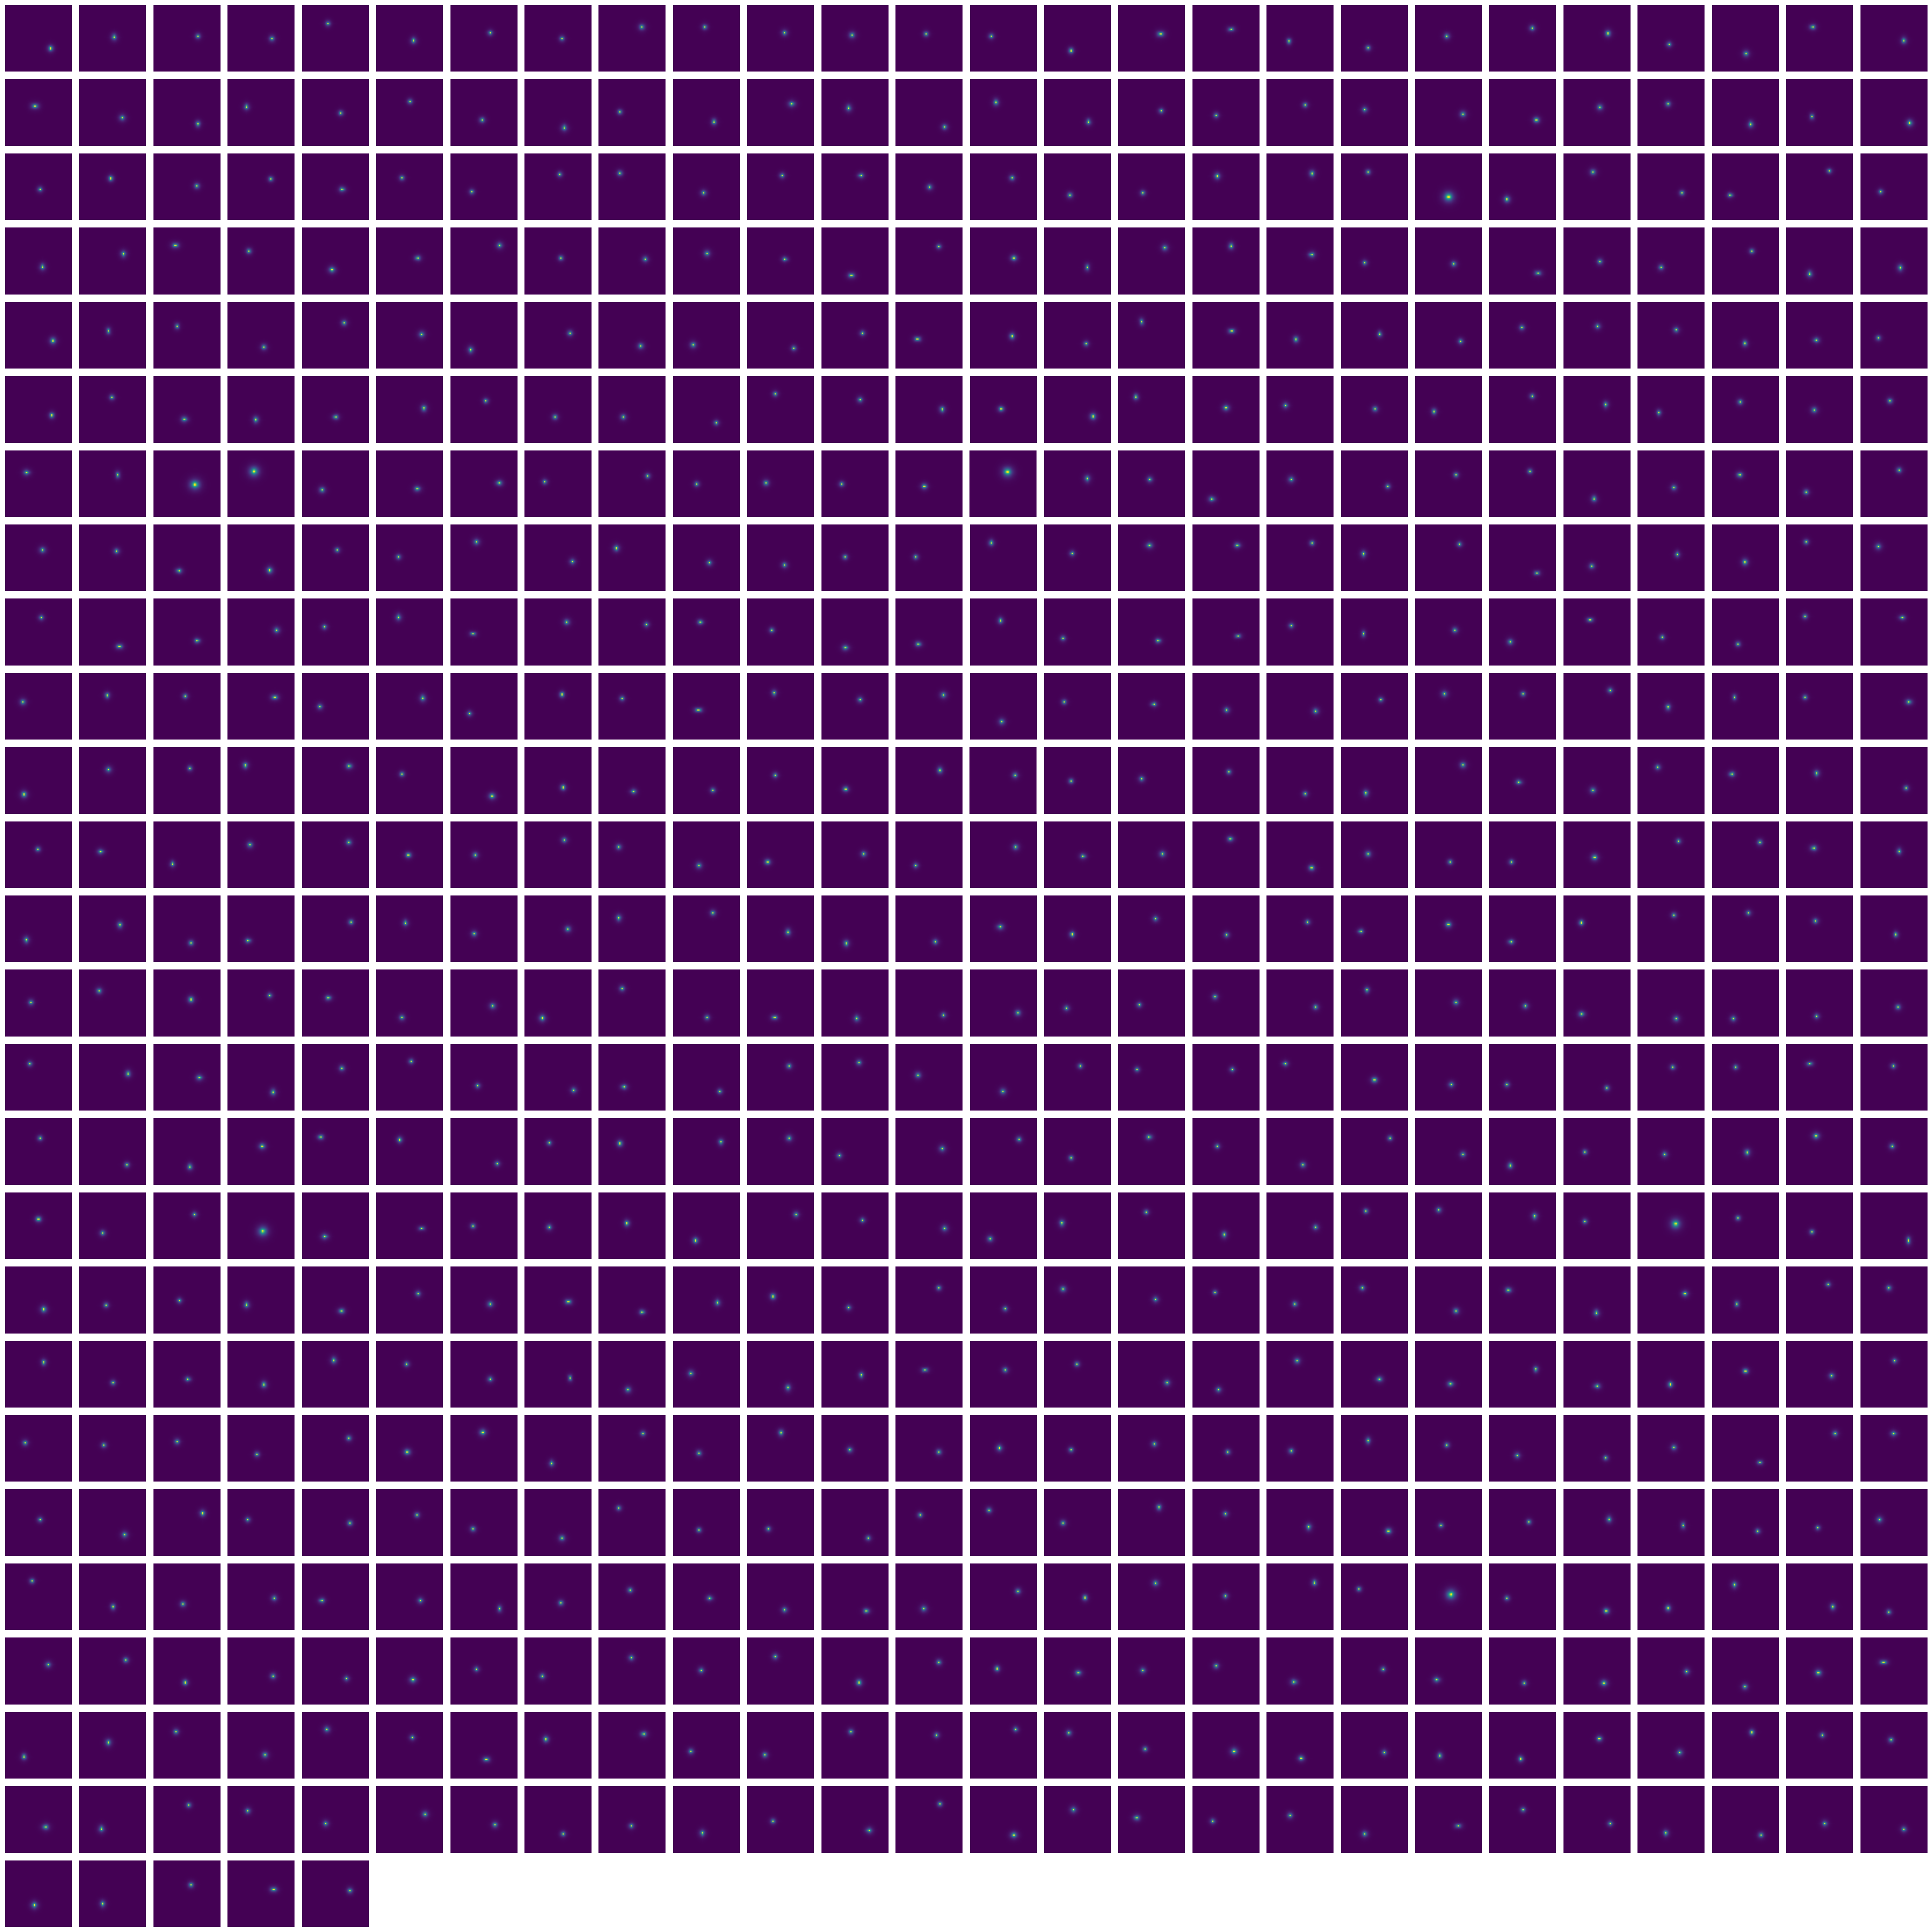

In [12]:
for c in [low_freq_centroids, mid_freq_centroids, high_freq_centroids]:
    f = c.squeeze(0).cpu()        # shape [N, 1024]
    print(f.shape)
    n = f.shape[0]
    size = int(math.sqrt(f.shape[1]))
    assert size * size == f.shape[1], "expected square (H*W)"

    cols = int(math.ceil(math.sqrt(n)))
    rows = int(math.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols*1.5, rows*1.5))
    axes = np.atleast_1d(axes).flatten()

    for i in range(rows * cols):
        ax = axes[i]
        if i < n:
            img = f[i].reshape(size, size).numpy()
            ax.imshow(img, cmap="viridis")
        ax.axis("off")

    plt.tight_layout()
    plt.show()